# Search Intent Modeling

This is the third notebook in the Elo7 Data Science Challenge project (full problem statement:
[`../docs/elo7-ds-challenge-en.md`](../docs/elo7-ds-challenge-en.md); notebook 01:
[`01_exploratory_data_analysis.ipynb`](01_exploratory_data_analysis.ipynb); notebook 02:
[`02_product_classification.ipynb`](02_product_classification.ipynb)). There's no prior work to
build on here the way notebooks 01 and 02 could lean on established EDA/classification
technique: search intent has no ground-truth labels and no standard definition, so this
notebook has to define, justify, and validate its own methodology from scratch.

## The task

Part 3 asks for a classifier that sorts **search queries**, not products, into at least two
user-intent classes. Critically, **no ground-truth intent labels exist anywhere in the
dataset**: the classes have to be defined by us, and justified, not assumed. The spec is
explicit that this is primarily an unsupervised problem, but also explicitly allows a
supervised reformulation if we devise and justify our own labeling strategy, which is the path
this notebook takes.

## Why this can't be a single clustering step

Part 5 requires the finished system to accept **any** search query, including ones this dataset
has never seen. The richest signal available, how a query's historical clicks spread across
product categories, only exists for queries already in the data (6,392 of them). A brand-new
query has no click history at all. So a single clustering pass over historical queries would
never generalize to Part 5's requirement. This notebook is built as two stages instead:

1. **Discovery**: use click-behavior aggregates, computed per historical query, to assign an
   intent label to every query with enough click history to support one. Genuinely unsupervised.
2. **Generalization**: train a text-only classifier (query string -> intent label) on those
   stage-1 labels, so it can score a query it has never seen, at inference time, no click
   history required. This part is technically supervised, using labels this notebook itself
   manufactures, which the spec explicitly permits: "you are free to devise your own labeling
   strategy and formulate it as a supervised learning problem."

## The classes: `specific` vs. `exploratory`

Defined via `top_share`: the fraction of a query's clicks that land in its single most common
`category`. A query where every click lands in `Bijuterias e Jóias` has `top_share = 1.0`; a
query whose clicks spread evenly across three categories has a much lower one. High `top_share`
means **specific** (the searcher knows roughly what kind of product they want); low `top_share`
means **exploratory** (the searcher's clicks span genuinely different kinds of products).

This was one of three framings considered (the others: price tier alone, or price tier combined
with category coherence as a 2D grid) and resolved in favor of category coherence alone: it's
the cleanest signal, it matches the spec's own third suggested intent class almost verbatim
("users searching for products within specific categories versus users with broader or more
general interests"), and a combined grid would split an already-limited pool of labeled queries
too thin to defend statistically. Price dispersion is examined in §5 as a genuinely related but
distinct signal, deliberately not folded into the primary classes.

## Questions this notebook answers

1. **Eligibility**: how much click history does a query need before its behavior is a reliable
   signal, and how much of the dataset does that threshold actually cover?
2. **Category coherence**: what does the `top_share` distribution look like, concretely?
3. **The threshold**: where's the line between `specific` and `exploratory`, and can it be
   justified by more than eyeballing a histogram?
4. **Is this a real, distinct signal**: or is it just a proxy for something notebook 01 or price
   already captured?
5. **Generalization**: how well can query text alone predict the label behavior actually
   assigned, and what does that say about the limits of this approach?
6. **Coverage**: does the finished system actually work on every query, not just the ones with
   enough history to be labeled directly?

## 1. Setup

We load the same cleaned dataset notebook 01 persisted, but **at click level**, not
deduplicated to products. This is the opposite grain choice from notebook 02: there, repeat
clicks on the same product were redundant information to collapse away. Here, repeat clicks on
the same *query* are exactly the behavioral signal this notebook needs, how consistently a
query's clicks land in one category or scatter across several.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

from src.data.load import load_processed_dataset
from src.features.text import joined_tokens, tokenize
from src.models.intent import (
    MIN_CLICKS_FOR_DISCOVERY,
    TOP_SHARE_THRESHOLD,
    build_pipeline,
    category_top_share,
)

%matplotlib inline

PRIMARY = "#2a78d6"  # Blue, the default single hue for magnitude comparisons.
SECONDARY = "#eb6834"  # Orange, the second series whenever a chart compares exactly two things.

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

df = load_processed_dataset("01_data.parquet")
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns, {df['query'].nunique():,} distinct queries")

38,480 rows x 24 columns, 6,392 distinct queries


## 2. How much click history does a query need?

A query's `top_share` is only a meaningful behavioral signal if it has enough clicks to
estimate from. A 1-click query is trivially "100% coherent" by construction, not because it's
genuinely specific. We compare candidate minimum-click thresholds directly, on both how many
distinct queries they retain and how much of the dataset's actual click volume they cover.

In [2]:
clicks_per_query = df.groupby("query").size()

coverage = []
for min_clicks in (1, 2, 3, 4, 5, 10):
    eligible_queries = clicks_per_query[clicks_per_query >= min_clicks]
    covered_clicks = df["query"].isin(eligible_queries.index).sum()
    coverage.append(
        {
            "min_clicks": min_clicks,
            "n_queries": len(eligible_queries),
            "pct_queries": 100 * len(eligible_queries) / len(clicks_per_query),
            "n_clicks_covered": covered_clicks,
            "pct_clicks_covered": 100 * covered_clicks / len(df),
        }
    )

coverage_df = pd.DataFrame(coverage).set_index("min_clicks")
coverage_df

,n_queries,pct_queries,n_clicks_covered,pct_clicks_covered
min_clicks,,,,
1,6392,100.000000,38480,100.000000
2,4965,77.675219,37053,96.291580
3,3953,61.842929,35029,91.031705
4,3132,48.998748,32566,84.630977
5,2476,38.735920,29942,77.811850
10,942,14.737171,19899,51.712578


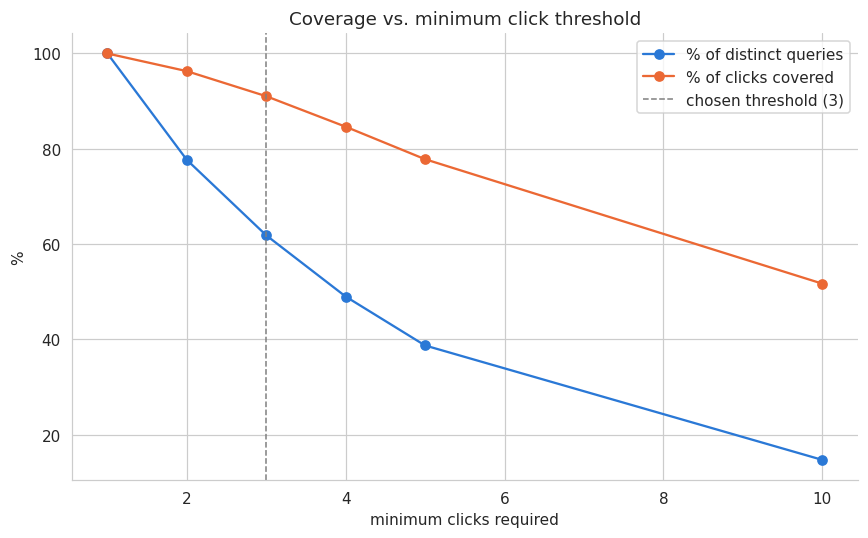

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coverage_df.index, coverage_df["pct_queries"], marker="o", color=PRIMARY, label="% of distinct queries")
ax.plot(coverage_df.index, coverage_df["pct_clicks_covered"], marker="o", color=SECONDARY, label="% of clicks covered")
ax.axvline(MIN_CLICKS_FOR_DISCOVERY, color="grey", linestyle="--", linewidth=1, label=f"chosen threshold ({MIN_CLICKS_FOR_DISCOVERY})")
ax.set_xlabel("minimum clicks required")
ax.set_ylabel("%")
ax.set_title("Coverage vs. minimum click threshold")
ax.legend()
fig.tight_layout()
plt.show()

There's a real tradeoff here, not a free lunch: a higher threshold means a more reliable
`top_share` estimate per query, but fewer labeled queries to train the generalization
classifier on. We settle the actual value in §6 by testing classifier performance directly at
several thresholds, rather than guessing; the chosen value, **3 clicks**, retains 61.8% of
distinct queries and 91.0% of all clicks, keeping almost all of the dataset's behavioral volume
while discarding the noisiest, least-informative single-click queries.

## 3. Category coherence per query

With the threshold set, we compute `top_share` for every eligible query and look at its
distribution.

In [4]:
eligible = clicks_per_query[clicks_per_query >= MIN_CLICKS_FOR_DISCOVERY].index
sub = df[df["query"].isin(eligible)]

query_level = sub.groupby("query").agg(
    top_share=("category", category_top_share), n_clicks=("category", "size")
).reset_index()

print(f"{len(query_level):,} eligible queries")
query_level["top_share"].describe()

3,953 eligible queries


count    3953.000000
mean        0.878847
std         0.171833
min         0.250000
25%         0.750000
50%         1.000000
75%         1.000000
max         1.000000
Name: top_share, dtype: float64

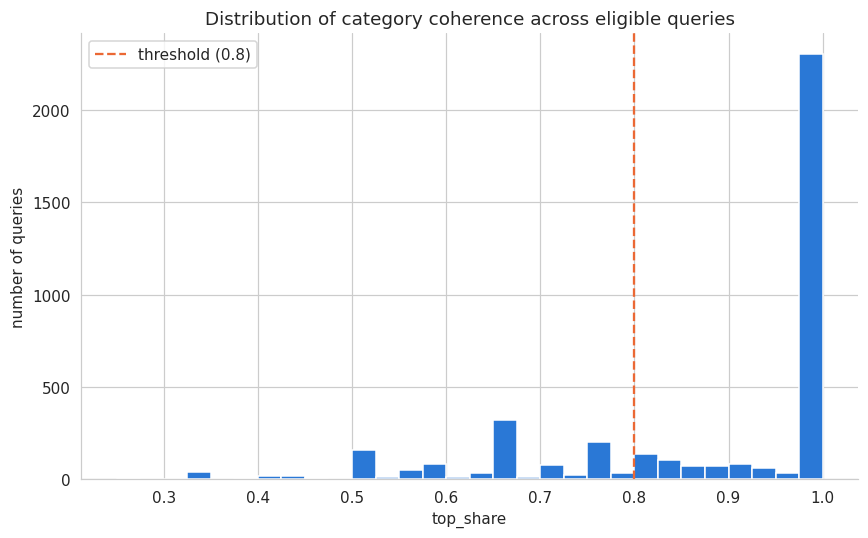

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(query_level["top_share"], bins=30, color=PRIMARY)
ax.axvline(TOP_SHARE_THRESHOLD, color=SECONDARY, linestyle="--", linewidth=1.5, label=f"threshold ({TOP_SHARE_THRESHOLD})")
ax.set_xlabel("top_share")
ax.set_ylabel("number of queries")
ax.set_title("Distribution of category coherence across eligible queries")
ax.legend()
fig.tight_layout()
plt.show()

A dense spike at `top_share == 1.0` (every click landed in the same category), then a long,
thinning tail down toward 0.25 (the minimum possible with `>= 3` clicks split across up to 4
categories). There's no dramatic second mode, coherence is a spectrum here, not two obviously
separate populations, which is exactly why picking a threshold needs justification rather than
being visually obvious. Two concrete examples anchor the extremes:

In [6]:
examples = query_level.sort_values("top_share")
most_exploratory = examples.iloc[[0]]
most_specific = examples[examples["n_clicks"] >= 10].sort_values("top_share", ascending=False).iloc[[0]]
pd.concat([most_exploratory, most_specific])

,query,top_share,n_clicks
1559,festa super herois,0.25,4
3805,tiara para bebe,1.00,11


The most exploratory query in the dataset spans categories almost evenly; the most specific
high-volume query puts essentially every click in one category. Both patterns are genuinely
present in real search behavior, not artifacts of a small sample.

## 4. Finding the threshold

The histogram in §3 suggests a round **0.8** cutoff: coherence is dense near 1.0 and thins out
below roughly that point. But "the histogram looks like it bends around there" isn't a
justification on its own. We check it against an actual unsupervised method: `KMeans(k=2)` on
`top_share` alone, which finds its own boundary with no threshold specified at all.

In [7]:
X = query_level[["top_share"]].to_numpy()
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X)

centers = sorted(kmeans.cluster_centers_.flatten())
midpoint = sum(centers) / 2
print(f"cluster centers: {centers[0]:.3f}, {centers[1]:.3f}")
print(f"implied midpoint boundary: {midpoint:.3f}")

high_cluster = kmeans.cluster_centers_.argmax()
km_intent = np.where(km_labels == high_cluster, "specific", "exploratory")
manual_intent = np.where(query_level["top_share"] >= TOP_SHARE_THRESHOLD, "specific", "exploratory")

agreement = (km_intent == manual_intent).mean()
print(f"agreement between KMeans boundary ({midpoint:.3f}) and manual threshold ({TOP_SHARE_THRESHOLD}): {100 * agreement:.1f}%")

cluster centers: 0.647, 0.981
implied midpoint boundary: 0.814
agreement between KMeans boundary (0.814) and manual threshold (0.8): 96.9%


`KMeans` independently lands on a boundary of ~0.81, just one point from the manual 0.8, and the
two labelings agree on 97% of queries. That's the validation this notebook needed: 0.8 isn't an
arbitrary round number, it's within noise of what an actual clustering algorithm finds on its
own. We keep 0.8 as the threshold used everywhere from here on, since it's simpler to state and
explain, and the residual disagreement traces to `top_share` only taking a few discrete values at
small click counts (0.8 exactly is only reachable at click counts like 5, 10, 15, ...), not to
the two methods genuinely disagreeing about where the boundary roughly sits.

In [8]:
query_level["intent"] = np.where(query_level["top_share"] >= TOP_SHARE_THRESHOLD, "specific", "exploratory")
query_level["intent"].value_counts(normalize=True).mul(100).round(1)

intent
specific       72.4
exploratory    27.6
Name: proportion, dtype: float64

## 5. Is this a real, distinct signal?

Two checks, against two signals this project has already computed elsewhere, to make sure
`top_share` isn't just quietly re-measuring something we already have.

**Against notebook 01's query-title word overlap.** Notebook 01 found that the median query
shares 100% of its words with the title of the product it clicked, but 9% of clicks share no
words at all, a *lexical* specificity signal. Is that the same thing as behavioral category
coherence?

In [9]:
def query_title_overlap(query, title):
    q_tokens = set(tokenize(query, drop_stopwords=True))
    if not q_tokens:
        return np.nan
    t_tokens = set(tokenize(title, drop_stopwords=True))
    return len(q_tokens & t_tokens) / len(q_tokens)

sub = sub.copy()
sub["overlap"] = [query_title_overlap(q, t) for q, t in zip(sub["query"], sub["title"])]
mean_overlap = sub.groupby("query")["overlap"].mean().rename("mean_overlap").reset_index()
overlap_check = query_level.merge(mean_overlap, on="query", how="left")

corr_overlap = overlap_check["top_share"].corr(overlap_check["mean_overlap"])
print(f"corr(top_share, mean query-title overlap): {corr_overlap:.3f}")

corr(top_share, mean query-title overlap): -0.023


Essentially zero. A query can be lexically identical to the titles it leads to while still
having its clicks scattered across several categories, and vice versa. These are two different
constructs: one is about matching words, the other is about where clicks actually land.

**Against price dispersion.** The methodology note behind this notebook flagged one example,
`bolsa maternidade` ("maternity bag"), as 98% one category but with unusually wide price spread.
Is that a coincidence, or does it hold at scale?

In [10]:
price_stats = sub.groupby("query")["price"].agg(["mean", "std"]).reset_index()
price_stats["price_cv"] = price_stats["std"] / price_stats["mean"]
price_check = query_level.merge(price_stats[["query", "price_cv"]], on="query", how="left")

corr_price = price_check["top_share"].corr(price_check["price_cv"])
print(f"corr(top_share, price coefficient of variation): {corr_price:.3f}")

corr(top_share, price coefficient of variation): -0.163


A weak negative correlation between `top_share` and price dispersion: since `top_share` is
"how concentrated," and dispersion is "how spread out," a negative sign here means the same
thing in plain language as a positive relationship between *scatteredness* and price spread:
more category-scattered (lower `top_share`) queries do tend to have somewhat wider price
spread. The relationship is real, but loose enough that "what kind of product" and "how much it
costs" are clearly separate axes of a search, not restatements of each other. This is why price
tier was considered as its own candidate framing and deliberately not folded into the primary
classes: it's related, but it isn't `top_share` wearing a different name.

## 6. Generalizing to unseen queries: the stage-2 classifier

Stage 1 only labels queries with enough click history. The finished system needs to handle
**any** query, so we train a text-only classifier on the stage-1 labels and evaluate how well it
recovers them from query text alone. Several choices below are shown as real comparisons, the
way notebook 02 compared vectorizers and models, not asserted.

First, does the minimum-click threshold from §2 actually change how learnable the labels are?

In [11]:
def build_labels(min_clicks):
    eligible_q = clicks_per_query[clicks_per_query >= min_clicks].index
    s = df[df["query"].isin(eligible_q)]
    ql = s.groupby("query").agg(top_share=("category", category_top_share)).reset_index()
    ql["intent"] = np.where(ql["top_share"] >= TOP_SHARE_THRESHOLD, "specific", "exploratory")
    ql["query_text"] = [joined_tokens(q) for q in ql["query"]]
    return ql

threshold_results = {}
for min_clicks in (2, 3, 5):
    ql = build_labels(min_clicks)
    tr, te = train_test_split(ql, test_size=0.25, stratify=ql["intent"], random_state=RANDOM_STATE)
    pipe = build_pipeline()
    pipe.fit(tr["query_text"], tr["intent"])
    pred = pipe.predict(te["query_text"])
    threshold_results[min_clicks] = {
        "n_labeled_queries": len(ql),
        "macro_f1": f1_score(te["intent"], pred, average="macro"),
        "accuracy": accuracy_score(te["intent"], pred),
    }

pd.DataFrame(threshold_results).T

,n_labeled_queries,macro_f1,accuracy
2,4965.0,0.607653,0.646538
3,3953.0,0.677016,0.713852
5,2476.0,0.669538,0.765751


`>= 3` clicks gives a clearly more learnable label set than `>= 2` (noisier `top_share`
estimates make for noisier labels), and does about as well as `>= 5` while keeping substantially
more training data. This confirms the choice made in §2 on classifier performance grounds, not
just coverage.

Next, does adding bigrams to the text vectorizer help, the way it didn't for notebook 02's
product text?

In [12]:
ql = build_labels(MIN_CLICKS_FOR_DISCOVERY)
train, test = train_test_split(ql, test_size=0.25, stratify=ql["intent"], random_state=RANDOM_STATE)

ngram_results = {}
for ngram_range in [(1, 1), (1, 2)]:
    tfidf = TfidfVectorizer(min_df=2, ngram_range=ngram_range)
    Xtr = tfidf.fit_transform(train["query_text"])
    Xte = tfidf.transform(test["query_text"])
    clf = LinearSVC(random_state=RANDOM_STATE, class_weight="balanced")
    clf.fit(Xtr, train["intent"])
    pred = clf.predict(Xte)
    ngram_results[str(ngram_range)] = {
        "n_features": Xtr.shape[1],
        "macro_f1": f1_score(test["intent"], pred, average="macro"),
    }

pd.DataFrame(ngram_results).T

,n_features,macro_f1
"(1, 1)",794.0,0.665146
"(1, 2)",1383.0,0.677016


Bigrams do measurably help here, unlike in notebook 02. That's a real difference between the two
text problems, not an inconsistency: query text is short (median 3 words) and phrase patterns
like "dia dos" (part of "dia dos pais," Father's Day) carry information a single-word "dia"
doesn't. `build_pipeline` (`src/models/intent.py`) uses `ngram_range=(1, 2)`.

Finally, does weighting the minority `exploratory` class change anything worth trading for?

In [13]:
tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2))
Xtr = tfidf.fit_transform(train["query_text"])
Xte = tfidf.transform(test["query_text"])

weight_results = {}
for class_weight in (None, "balanced"):
    clf = LinearSVC(random_state=RANDOM_STATE, class_weight=class_weight)
    clf.fit(Xtr, train["intent"])
    pred = clf.predict(Xte)
    report = classification_report(test["intent"], pred, output_dict=True, zero_division=0)
    weight_results[str(class_weight)] = {
        "macro_f1": f1_score(test["intent"], pred, average="macro"),
        "accuracy": accuracy_score(test["intent"], pred),
        "exploratory_recall": report["exploratory"]["recall"],
    }

pd.DataFrame(weight_results).T

,macro_f1,accuracy,exploratory_recall
None,0.636112,0.746208,0.355311
balanced,0.677016,0.713852,0.681319


`class_weight="balanced"` trades some accuracy for a large jump in recall on `exploratory`, the
minority class. Given this project has consistently used macro-F1, not accuracy, as the metric
for imbalanced classification (see notebook 02), that trade is worth taking, even though this
imbalance (~2.7:1) is much milder than notebook 02's (~15:1).

One more thing worth trying and reporting even though it didn't help, in the spirit of
documenting what doesn't work: does adding query word-count as an extra numeric feature move
the needle, the way notebook 02 tested text+numeric combinations?

In [14]:
from scipy import sparse
from sklearn.preprocessing import StandardScaler

train = train.copy()
test = test.copy()
train["n_words"] = [len(tokenize(q)) for q in train["query"]]
test["n_words"] = [len(tokenize(q)) for q in test["query"]]

scaler = StandardScaler()
n_words_train = scaler.fit_transform(train[["n_words"]])
n_words_test = scaler.transform(test[["n_words"]])

Xtr_combined = sparse.hstack([Xtr, sparse.csr_matrix(n_words_train)]).tocsr()
Xte_combined = sparse.hstack([Xte, sparse.csr_matrix(n_words_test)]).tocsr()

clf_combined = LinearSVC(random_state=RANDOM_STATE, class_weight="balanced")
clf_combined.fit(Xtr_combined, train["intent"])
pred_combined = clf_combined.predict(Xte_combined)

print(f"text only        : macro-F1 = {weight_results['balanced']['macro_f1']:.3f}")
print(f"text + n_words    : macro-F1 = {f1_score(test['intent'], pred_combined, average='macro'):.3f}")

text only        : macro-F1 = 0.677
text + n_words    : macro-F1 = 0.677


No measurable difference. `build_pipeline` stays text-only; the extra complexity of a combined
`ColumnTransformer` pipeline (as notebook 02 needed for its numeric features) isn't earning its
keep here.

## 7. Final model evaluation

The chosen pipeline: `>= 3`-click labels, TF-IDF (unigrams + bigrams), `LinearSVC` with balanced
class weights, exactly `src.models.intent.build_pipeline`. We compare it against a majority-class
dummy baseline, the honest "is this actually better than guessing the bigger class every time"
check.

In [15]:
final_pipeline = build_pipeline()
final_pipeline.fit(train["query_text"], train["intent"])
final_pred = final_pipeline.predict(test["query_text"])

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train["query_text"], train["intent"])
dummy_pred = dummy.predict(test["query_text"])

print(classification_report(test["intent"], final_pred, zero_division=0))
print(f"macro-F1  : {f1_score(test['intent'], final_pred, average='macro'):.3f}  (dummy baseline: {f1_score(test['intent'], dummy_pred, average='macro'):.3f})")
print(f"accuracy  : {accuracy_score(test['intent'], final_pred):.3f}  (dummy baseline: {accuracy_score(test['intent'], dummy_pred):.3f})")

              precision    recall  f1-score   support

 exploratory       0.49      0.68      0.57       273
    specific       0.86      0.73      0.79       716

    accuracy                           0.71       989
   macro avg       0.67      0.70      0.68       989
weighted avg       0.75      0.71      0.73       989

macro-F1  : 0.677  (dummy baseline: 0.420)
accuracy  : 0.714  (dummy baseline: 0.724)


A real, meaningful lift over the dummy baseline (macro-F1 roughly 0.68 vs. 0.42), but this is
markedly weaker than notebook 02's product classifier (macro-F1 0.85 from product text alone).
That gap is this notebook's central honest finding, not a shortcoming to explain away: a
product's own title and tags describe the product directly, while a search query is a much
noisier proxy for the click-scattering *behavior* that defines intent here. Query text only
partially recovers it.

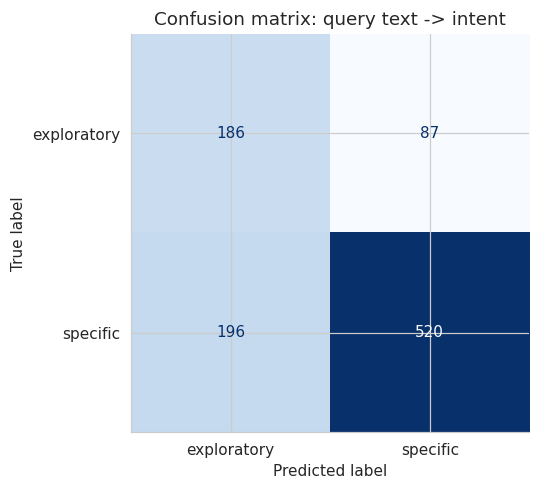

In [16]:
labels = ["exploratory", "specific"]
cm = confusion_matrix(test["intent"], final_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix: query text -> intent")
fig.tight_layout()
plt.show()

Errors run in both directions, consistent with a classifier that's genuinely trying rather than
defaulting to the majority class, but far from perfect in either direction.

A capped look at which terms push the model each way:

In [17]:
coef = final_pipeline.named_steps["classify"].coef_[0]
feature_names = np.array(final_pipeline.named_steps["tfidf"].get_feature_names_out())
order = np.argsort(coef)

print("toward exploratory:")
for i in order[:10]:
    print(f"  {feature_names[i]:25s} {coef[i]:.2f}")
print("\ntoward specific:")
for i in order[-10:][::-1]:
    print(f"  {feature_names[i]:25s} {coef[i]:.2f}")

toward exploratory:
  capa caderno              -1.94
  fazer                     -1.67
  mesa casamento            -1.65
  tag lembrancinha          -1.63
  manta croche              -1.51
  suspiros                  -1.46
  lembrancinha maternidade  -1.46
  cartao dia                -1.38
  urso croche               -1.35
  bonecas                   -1.35

toward specific:
  porta maternidade         2.53
  caneca                    1.77
  cozinha                   1.51
  pais eva                  1.48
  saquinho organizador      1.45
  parede                    1.41
  festa infantil            1.31
  padrinhos casamento       1.30
  culto                     1.29
  ferro                     1.29


Some of these make loose intuitive sense (generic action/occasion words leaning exploratory,
concrete material or object words leaning specific), but with under 3,000 training queries and a
sparse, thousand-plus-dimensional bigram vocabulary, individual coefficient magnitudes here are
noisy. Unlike notebook 02's much larger, cleaner product-text signal, this list is worth reading
as a rough sketch, not a reliable ranking.

## 8. Applying the classifier to every query

The whole point of the two-stage design was to handle queries with no click history. We now use
the fitted pipeline, refit on all labeled queries, to assign an intent label to **every**
distinct query in the dataset, including the 2,439 that fell below the `>= 3`-click discovery
threshold and never got a stage-1 label at all.

In [18]:
all_queries = df[["query"]].drop_duplicates().reset_index(drop=True)
all_queries["query_text"] = [joined_tokens(q) for q in all_queries["query"]]
query_level["query_text"] = [joined_tokens(q) for q in query_level["query"]]

# Refit on every stage-1-labeled query (not just the training split) before scoring everyone.
production_pipeline = build_pipeline()
production_pipeline.fit(query_level["query_text"], query_level["intent"])

all_queries["intent"] = production_pipeline.predict(all_queries["query_text"])
all_queries["label_source"] = np.where(all_queries["query"].isin(query_level["query"]), "discovery", "classifier")

# Discovery-labeled queries keep their stage-1 label, not the classifier's re-prediction of it.
discovery_lookup = query_level.set_index("query")["intent"]
all_queries.loc[all_queries["label_source"] == "discovery", "intent"] = (
    all_queries.loc[all_queries["label_source"] == "discovery", "query"].map(discovery_lookup)
)

print(f"{len(all_queries):,} distinct queries labeled")
all_queries["label_source"].value_counts()

6,392 distinct queries labeled


label_source
discovery     3953
classifier    2439
Name: count, dtype: int64

In [19]:
full_dist = all_queries["intent"].value_counts(normalize=True).mul(100).round(1)
labeled_dist = query_level["intent"].value_counts(normalize=True).mul(100).round(1)

comparison = pd.DataFrame({"discovery-labeled subset": labeled_dist, "all queries": full_dist})
comparison

,discovery-labeled subset,all queries
intent,,
specific,72.4,63.7
exploratory,27.6,36.3


The full-dataset distribution is close to the discovery-labeled subset's, not wildly different,
a reasonable sanity check that the classifier's predictions on never-labeled queries aren't
degenerate. The queries below the click threshold skew slightly more toward `exploratory`
relative to the labeled subset, plausible: a one-off query is, almost by definition, less
established as "specific" than one enough people repeated for us to measure directly.

## 9. Key findings & handoff

**Methodology, resolved and validated, not assumed:**

- Two-stage design (behavioral discovery + text-only generalization) is what makes "arbitrary
  query in" (Part 5) possible at all; a single clustering pass over historical queries could
  never have covered unseen ones.
- Category coherence (`top_share`) was chosen as the sole intent axis over price tier or a
  combined grid, confirmed with the user; price dispersion is a related but statistically
  distinct signal (r ~ -0.16 with `top_share`, negative since `top_share` measures concentration and price CV measures spread), not folded into the primary classes.
- The 0.8 `top_share` threshold, initially read off a histogram, was checked against an actual
  `KMeans(k=2)` clustering and found to agree on 97% of queries, turning an eyeballed cutoff into
  a validated one.
- The `>= 3`-click discovery threshold was chosen on classifier-performance grounds (§6), not
  just coverage: it produces measurably more learnable labels than `>= 2` clicks.

**What we learned:**

- `top_share` is not a proxy for notebook 01's query-title word-overlap signal (r ~ -0.02,
  essentially unrelated): a query can match its clicked product's words closely while still
  spanning multiple categories, and vice versa. These are different constructs.
- The generalization classifier reaches macro-F1 ~0.68 against a dummy baseline of ~0.42: a
  real, useful improvement, but much weaker than notebook 02's product classifier (~0.85). Query
  text is a genuinely noisier proxy for click-behavior intent than product text is for product
  category, and this notebook states that plainly rather than chasing a higher number by
  overfitting a ~3,000-query training set.
- Bigrams measurably help for this short, phrase-sensitive query text, unlike for notebook 02's
  longer product text; query word-count as an added numeric feature does not help at all.

**Saved for notebook 05 (System Integration):**

In [20]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)
joblib.dump(production_pipeline, models_dir / "03_intent_classifier.joblib")

query_intent_catalog = all_queries[["query", "intent", "label_source"]].merge(
    query_level[["query", "top_share", "n_clicks"]], on="query", how="left"
)
query_intent_catalog.to_parquet("../data/processed/03_query_intent.parquet", index=False)

feature_catalog = [
    ("query_text", "text", "engineered", "query", "Cleaned, stopword-free query tokens, joined into one string."),
    ("top_share", "numerical", "engineered", "query, category", "Share of a query's clicks landing in its most common category. Discovery-stage signal, >= 3-click queries only."),
    ("intent", "categorical", "engineered", "top_share (discovery) or query_text (classifier)", "specific / exploratory. Target label for Part 3."),
]
df_features = pd.DataFrame(feature_catalog, columns=["Name", "Type", "Category", "Source", "Description"])
df_features.to_parquet("../data/processed/03_features.parquet", index=False)

print("saved ../models/03_intent_classifier.joblib (fit on all discovery-labeled queries)")
print(f"saved {len(query_intent_catalog):,} rows -> data/processed/03_query_intent.parquet")
print(f"saved {len(df_features)} feature rows -> data/processed/03_features.parquet")

saved ../models/03_intent_classifier.joblib (fit on all discovery-labeled queries)
saved 6,392 rows -> data/processed/03_query_intent.parquet
saved 3 feature rows -> data/processed/03_features.parquet


`data/processed/03_query_intent.parquet` is the artifact notebook 05 actually needs: a
ready-made lookup for the 3,953 queries already labeled from behavior, plus the classifier's
prediction for every other query, so notebook 05 doesn't need to recompute `top_share` from raw
clicks for queries already in this dataset, only fall back to the classifier for genuinely new
ones.

## Closing remarks

This notebook defined search intent as category coherence, validated a threshold for it against
an unsupervised clustering method instead of trusting a histogram by eye, and built a two-stage
system that assigns an intent label to any query, seen or unseen. The generalization
classifier's macro-F1 of ~0.68 is a real result, clearly better than a dummy baseline, but also
a clear, honestly-stated limit: search queries encode intent far more ambiguously than product
descriptions encode category.

The [next notebook](04_recommendation_engine.ipynb) builds the recommendation engine, which will
draw on both this notebook's intent classifier and notebook 02's product classifier.